# **Analisis Sentimen Ulasan Jenius Bank**

### Ujian Akhir Semester
**Eksplorasi dan Visualisasi Data**

---

**Nama** : Marcella Ariani  
**NIM** : 20254920003  
**Program Studi** : Statistika  
**Fakultas** : Sains, Komputer dan Matematika  
**Universitas** : Universitas Matana  


Tahun Akademik 2025/2026

---

**Pada analisis ini dilakukan pengambilan data ulasan pengguna aplikasi Jenius Bank (PT Bank SMBC Indonesia Tbk) yang tersedia di Google Play Store. Pengambilan data dilakukan menggunakan library Google Play Scraper dengan jumlah data sebanyak 1.000 ulasan terbaru. Data yang diperoleh terdiri dari review pengguna, rating, serta informasi pendukung lainnya.**

**Pemilihan aplikasi Jenius Bank didasarkan pada popularitasnya sebagai salah satu layanan perbankan digital di Indonesia. Berdasarkan informasi di Google Play Store, aplikasi Jenius Bank memiliki rating sebesar 3,3 yang menunjukkan adanya beragam pengalaman pengguna, baik positif maupun negatif. Oleh karena itu, ulasan pengguna pada Google Play Store menjadi sumber data yang relevan untuk menganalisis tingkat kepuasan serta sentimen pengguna terhadap aplikasi Jenius Bank.**

### **Import Dependencies** ###

In [2]:
# Import necessary libraries
from urllib.parse import urlparse, parse_qs
from google_play_scraper import reviews, Sort
import pandas as pd

**Pada tahap ini dilakukan import library yang dibutuhkan selama proses analisis. Library google_play_scraper digunakan untuk mengambil data ulasan aplikasi Jenius Bank dari Google Play Store. Library pandas digunakan untuk mengelola dan mengolah data dalam bentuk tabel (DataFrame), sedangkan urllib.parse digunakan untuk mengambil package name aplikasi dari URL Google Play Store.**

### **Extract Package Name from Google Play URL** ###

In [3]:
# Function to extract package name from Google Play URL
def get_package_name(play_store_url):
    parsed_url = urlparse(play_store_url)
    query_params = parse_qs(parsed_url.query)
    return query_params.get('id', [None])[0]

# Define Google Play Store URL
url = "https://play.google.com/store/apps/details?id=com.btpn.dc"

# Extract package name
package_name = get_package_name(url)
print("Extracted Package Name:", package_name)

Extracted Package Name: com.btpn.dc


**Tahap ini bertujuan untuk mengambil package name aplikasi dari URL Google Play Store. Package name diperlukan oleh Google Play Scraper agar sistem dapat mengetahui aplikasi mana yang akan diambil ulasannya.**

### **Fetch Google Play Reviews** ###

In [4]:
# Fetch reviews using the extracted package name
app_reviews, _ = reviews(
    package_name,
    lang='id',   # Language: Indonesia
    country='id',  # Country: Indonesian
    count= 1000,   # Fetch 1000 reviews to allow filtering
    sort= Sort.NEWEST  # Get the latest reviews
)

# Convert reviews to a DataFrame
df = pd.DataFrame(app_reviews)

# Display
df

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,3556f34b-5667-472f-9cf1-c79d83f87ee0,miftah rozi,https://play-lh.googleusercontent.com/a/ACg8oc...,Tidak bisa memasukan sandi(registrasi),1,0,4.75.1,2026-06-12 20:35:28,"Hi, Miftah Rozi. Mohon maaf atas kendala regis...",2026-06-12 20:39:45,4.75.1
1,6311a276-2c81-4a46-a311-fc870d8b0174,Almursy Almursyi,https://play-lh.googleusercontent.com/a-/ALV-U...,Duh tambah parah.,1,0,4.74.2,2026-06-12 20:31:21,"Hi, Almursy Almursyi. Mohon maaf atas ketidakn...",2026-06-12 20:36:22,4.74.2
2,28f29770-52c7-425a-8b0f-de1941bf6512,pwetty cia,https://play-lh.googleusercontent.com/a-/ALV-U...,"pls mba"" nya gausa maksa banget, suru tf 2,1 g...",1,0,NaN,2026-06-12 17:21:06,"Hi, Pwetty cia. Mohon maaf atas ketidaknyamana...",2026-06-12 17:23:55,NaN
3,8f8a78a0-a5a8-410f-b31e-935e947f71b2,Putri Dewi,https://play-lh.googleusercontent.com/a-/ALV-U...,Tidak support di device Huawei.. Mengecewakan ...,2,0,4.74.2,2026-06-12 10:20:04,Hi Kak Putri Dewi. Terima kasih atas ulasan ya...,2026-06-12 10:22:26,4.74.2
4,056f7913-98d1-4c2b-9e99-89c0dcd4c625,Nini Bear,https://play-lh.googleusercontent.com/a-/ALV-U...,"sdh dftr,sdh video call juga,tp tiap log in di...",1,0,NaN,2026-06-12 08:33:59,Hi Kak Nini Bear. Mohon maaf atas ketidaknyama...,2026-06-12 08:36:14,NaN
...,...,...,...,...,...,...,...,...,...,...,...
995,b80941af-07f8-4afe-ae9d-de2f91393dde,ABANG FAHRIEL,https://play-lh.googleusercontent.com/a-/ALV-U...,Aplikasi ini juga dpt membantu kita dalam memb...,5,3,4.51.1,2025-11-17 22:04:57,Hi ABANG FAHRIEL. Terima kasih atas ulasan dan...,2025-11-17 22:06:56,4.51.1
996,0390ddbe-e7fa-4f91-8ae6-3dc001f1abf7,Marcel Pren nata,https://play-lh.googleusercontent.com/a/ACg8oc...,aplikasi nya sangat bagus,5,0,NaN,2025-11-17 16:49:50,Hi Kak Marcel Pren nata. Terima kasih atas ula...,2025-11-17 16:51:25,NaN
997,5a90fdfd-6432-40e9-b41f-65d69dd9ed8f,Dwi Nuraini,https://play-lh.googleusercontent.com/a/ACg8oc...,kenapa sekarang jenius kelogout sendiri pas ki...,2,3,4.51.1,2025-11-17 13:59:50,Mohon maaf atas ketidaknyamanan yang kamu alam...,2025-11-17 14:54:08,4.51.1
998,079d429d-07dd-446e-85f9-2c723148105a,nana rusmana,https://play-lh.googleusercontent.com/a/ACg8oc...,"aplikasi ga jelas, kalo ga punya modal jgn ses...",1,9,4.51.1,2025-11-17 12:17:55,Mohon maaf atas ketidaknyamanannya. Informasi ...,2025-11-06 19:15:04,4.51.1


### **Filter Required Columns** ###

In [5]:
# Select only the required columns: 'reviewId', 'content', and 'score'
df_filtered_columns = df[['reviewId', 'content', 'score']]

# Display the result
df_filtered_columns

,reviewId,content,score
0,3556f34b-5667-472f-9cf1-c79d83f87ee0,Tidak bisa memasukan sandi(registrasi),1
1,6311a276-2c81-4a46-a311-fc870d8b0174,Duh tambah parah.,1
2,28f29770-52c7-425a-8b0f-de1941bf6512,"pls mba"" nya gausa maksa banget, suru tf 2,1 g...",1
3,8f8a78a0-a5a8-410f-b31e-935e947f71b2,Tidak support di device Huawei.. Mengecewakan ...,2
4,056f7913-98d1-4c2b-9e99-89c0dcd4c625,"sdh dftr,sdh video call juga,tp tiap log in di...",1
...,...,...,...
995,b80941af-07f8-4afe-ae9d-de2f91393dde,Aplikasi ini juga dpt membantu kita dalam memb...,5
996,0390ddbe-e7fa-4f91-8ae6-3dc001f1abf7,aplikasi nya sangat bagus,5
997,5a90fdfd-6432-40e9-b41f-65d69dd9ed8f,kenapa sekarang jenius kelogout sendiri pas ki...,2
998,079d429d-07dd-446e-85f9-2c723148105a,"aplikasi ga jelas, kalo ga punya modal jgn ses...",1


**Tidak semua atribut hasil scraping digunakan dalam penelitian ini. Oleh karena itu dilakukan seleksi kolom sehingga hanya menyisakan:**
| Kolom    | Fungsi           |
| -------- | ---------------- |
| reviewId | Identitas review |
| content  | Isi ulasan       |
| score    | Rating pengguna  |

**Ketiga atribut tersebut dianggap paling relevan untuk analisis sentimen.**

### **Sentiment Google PlayStore** ###

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Inisialisasi lemmatizer dan daftar stopwords bahasa Indonesia
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('indonesian'))

def preprocess_text(text):
    # Jika teks kosong atau bukan string, kembalikan string kosong
    if not isinstance(text, str):
        return ""

    # 1. Case Folding: Mengubah teks menjadi huruf kecil semua (lowercase)
    text = text.lower()

    # 2. Menghapus URL/Link (jika ada)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Menghapus tanda baca dan karakter spesial
    text = re.sub(r'[^\w\s]', '', text)

    # 4. Menghapus angka (opsional, tapi berguna untuk analisis teks umum)
    text = re.sub(r'\d+', '', text)

    # 5. Menghapus emoji (opsional, tapi bisa membantu membersihkan teks)
    text = re.sub(
    r"["
    u"\U0001F600-\U0001F64F"
    u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F6FF"
    u"\U0001F1E0-\U0001F1FF"
    "]+",
    '',
    text
    )

    # 6. Menghapus mention (@username) dan hashtag (#hashtag) jika ada  
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    
    # 7. Tokenization & Stopwords Removal & Lemmatization
    # Memecah kalimat menjadi kata-kata, memfilter stopwords, lalu mengubah ke kata dasar
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    # 8. Menggabungkan kata-kata kembali menjadi satu kalimat utuh
    return ' '.join(cleaned_words)

# Menghindari peringatan SettingWithCopyWarning dari pandas
df_filtered_columns = df_filtered_columns.copy()

# Mengaplikasikan fungsi preprocessing ke kolom 'content'
df_filtered_columns['cleaned_text'] = df_filtered_columns['content'].apply(preprocess_text)

# Membuat output yang hanya berisi text asli dan cleaned text sesuai permintaan
output_df = df_filtered_columns[['content', 'cleaned_text']]

# Menampilkan 100 baris pertama dari hasilnya
output_df.head(100)

,content,cleaned_text
0,Tidak bisa memasukan sandi(registrasi),memasukan sandiregistrasi
1,Duh tambah parah.,duh parah
2,"pls mba"" nya gausa maksa banget, suru tf 2,1 g...",pls mba nya gausa maksa banget suru tf giliran...
3,Tidak support di device Huawei.. Mengecewakan ...,support device huawei mengecewakan semoga perb...
4,"sdh dftr,sdh video call juga,tp tiap log in di...",sdh dftrsdh video call jugatp log in disuruh r...
...,...,...
95,dr segi apk udh oke. Tp dr segi marketing gak ...,dr segi apk udh oke tp dr segi marketing gak b...
96,aplikasi sampah login lemot nya minta ampun sa...,aplikasi sampah login lemot nya ampun saran me...
97,aplikasi konyol GK brmutu cuma ngambil data or...,aplikasi konyol gk brmutu ngambil data orang a...
98,Aplikasi perbankan terburuk yang pernah saya g...,aplikasi perbankan terburuk bisabisanya akun l...


### **Membuat World Cloud** ###

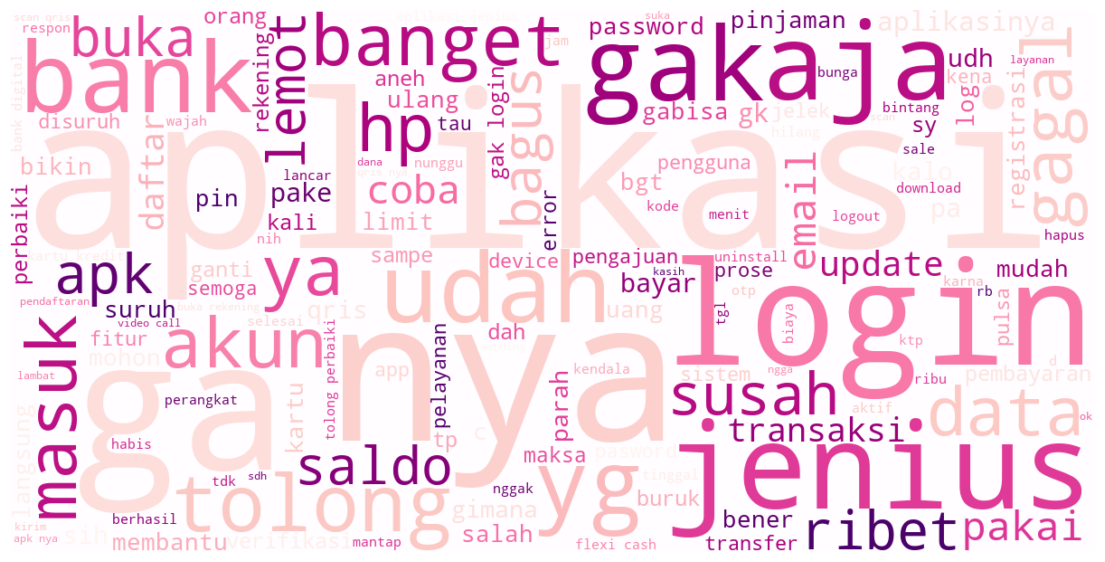

In [7]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_text = ' '.join(output_df['cleaned_text'])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="#FFFDFF",  # baby pink sangat muda
    colormap='RdPu',
    max_words=150
).generate(all_text)

plt.figure(figsize=(14,8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

**Word Cloud digunakan untuk menampilkan kata-kata yang paling sering muncul pada ulasan pengguna. Semakin besar ukuran kata pada Word Cloud maka semakin sering kata tersebut muncul dalam kumpulan ulasan. Visualisasi ini membantu memahami topik utama yang sering dibahas oleh pengguna Jenius Bank.**

### **Mencari Frekuensi yang Paling Sering Muncul** ###

         Word  Frequency
44   aplikasi        269
6         nya        258
77     jenius        200
88      login        190
98         ga        175
17        aja        142
174       gak        140
168      bank        122
75     tolong        115
95       udah        104
202        yg         91
40       data         82
122     gagal         79
89         hp         77
171     masuk         76
111      akun         75
139     susah         71
9      banget         71
101       apk         70
80         ya         70


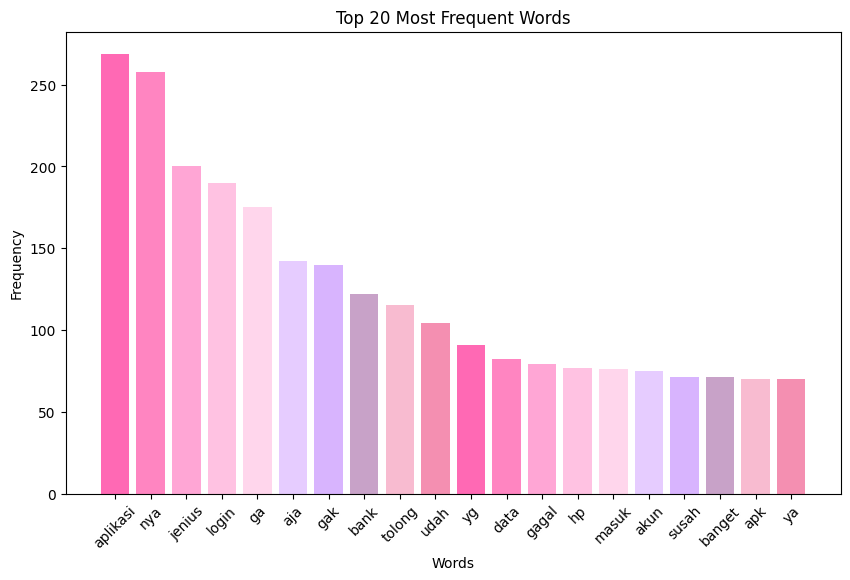

In [8]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import viridis_r
from matplotlib.colors import Normalize

# Split all cleaned text into individual words
all_words = ' '.join(output_df['cleaned_text']).split()

# Count the frequency of each word
word_counts = Counter(all_words)

# Convert the counts to a DataFrame for easier analysis
word_freq_df = pd.DataFrame(word_counts.items(), columns=['Word', 'Frequency']).sort_values(by='Frequency', ascending=False)

# Display the top 20 most frequent words
print(word_freq_df.head(20))

# Prepare inverted viridis colormap
top_words = word_freq_df.head(20)
norm = Normalize(vmin=min(top_words['Frequency']), vmax=max(top_words['Frequency']))
colors = colors = [
    '#FF69B4',
    '#FF85C1',
    '#FFA6D5',
    '#FFC2E2',
    '#FFD6EC',
    '#E6CCFF',
    '#D8B4FE',
    '#C8A2C8',
    '#F8BBD0',
    '#F48FB1'
]

# Show a bar plot of the top 20 most frequent words with inverted viridis
plt.figure(figsize=(10, 6))
plt.bar(top_words['Word'], top_words['Frequency'], color=colors)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Words')
plt.xticks(rotation=45)
plt.show()

**Selain Word Cloud, dilakukan perhitungan frekuensi kata menggunakan Counter. Tujuannya adalah untuk mengetahui secara kuantitatif kata-kata yang paling banyak muncul dalam ulasan. Hasilnya divisualisasikan dalam bentuk Bar Chart sehingga lebih mudah dibandingkan antar kata.**

### **TF-IDF** ###

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.stem.porter import PorterStemmer

# 1. Initialize the stemmer
porter = PorterStemmer()

# 2. Define the tokenizer function
def tokenizer_porter(text):
    return [porter.stem(word) for word in text.split()]

# 3. Define TF-IDF vectorizer
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        tokenizer=tokenizer_porter,
                        token_pattern=None,
                        use_idf=True,
                        norm='l2',
                        smooth_idf=True)

# Fit and transform your cleaned text
tfidf_matrix = tfidf.fit_transform(output_df['cleaned_text'])
print(tfidf_matrix.shape)

(1000, 2935)


**Karena algoritma machine learning tidak dapat membaca teks secara langsung, maka teks perlu diubah menjadi bentuk numerik. Metode yang digunakan adalah TF-IDF (Term Frequency-Inverse Document Frequency). TF-IDF memberikan bobot pada setiap kata berdasarkan tingkat kepentingannya dalam suatu dokumen. Kata yang dianggap penting akan memiliki bobot lebih tinggi dibandingkan kata yang sering muncul di seluruh dokumen.**

### **Label Sentimen** ###

In [10]:

from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Membuat kolom label 'sentiment' berdasarkan 'score'
df_filtered_columns['sentiment'] = df_filtered_columns['score'].apply(lambda x: 1 if x > 3 else 0)

# 2. Inisialisasi TF-IDF Vectorizer (menggunakan default tokenizer)
tfidf = TfidfVectorizer(strip_accents=None,
                        lowercase=False,
                        use_idf=True,
                        norm='l2',
                        smooth_idf=True)

# 3. Transformasi teks yang sudah dibersihkan (cleaned_text) menjadi matriks fitur (X)
X = tfidf.fit_transform(df_filtered_columns['cleaned_text'])

# 4. Target variabel (Y)
y = df_filtered_columns['sentiment']

print("Dimensi fitur X:", X.shape)
print("Dimensi target y:", y.shape)

Dimensi fitur X: (1000, 2939)
Dimensi target y: (1000,)


**Label sentimen dibentuk berdasarkan rating pengguna.**
| Rating | Sentimen |
| ------ | -------- |
| 4–5    | Positif  |
| 1–3    | Negatif  |

**Pendekatan ini digunakan karena rating dianggap mewakili tingkat kepuasan pengguna terhadap aplikasi.**

### **Split Data** ###

In [11]:
from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {X_train.shape[0]}")
print(f"Jumlah data testing: {X_test.shape[0]}")

Jumlah data training: 800
Jumlah data testing: 200


**Dataset dibagi menjadi:**

80% data training
20% data testing

**Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk mengukur performa model pada data yang belum pernah dilihat sebelumnya.**

### **Model Logistic Regression** ###

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Inisialisasi model Logistic Regression
model = LogisticRegression(class_weight='balanced')

# 2. Melatih (Training) model menggunakan data train
model.fit(X_train, y_train)

# 3. Memprediksi data test
y_pred = model.predict(X_test)

# 4. Menghitung dan menampilkan Akurasi
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model: {accuracy * 100:.2f}%\n")

# 5. Menampilkan laporan klasifikasi lengkap
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

Akurasi Model: 83.00%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.90      0.89       158
    Positive       0.60      0.57      0.59        42

    accuracy                           0.83       200
   macro avg       0.74      0.74      0.74       200
weighted avg       0.83      0.83      0.83       200



**Pada penelitian ini digunakan algoritma Logistic Regression untuk melakukan klasifikasi sentimen. Model dilatih menggunakan data training agar dapat mengenali pola kata yang berhubungan dengan sentimen positif maupun negatif. Setelah proses pelatihan selesai, model digunakan untuk memprediksi sentimen pada data testing.**

### **Prediction Sentiment** ###

In [13]:
def predict_sentiment(text):
    # Preprocess teks menggunakan fungsi 'preprocess_text' yang sudah kamu buat di awal
    cleaned_input = preprocess_text(text)

    # Ubah teks ke dalam format TF-IDF
    vectorized_input = tfidf.transform([cleaned_input])

    # Lakukan prediksi
    prediction = model.predict(vectorized_input)

    # Kembalikan hasil berupa string
    return "Positive" if prediction[0] == 1 else "Negative"

# Mari kita uji dengan kalimat baru!
test_sentence_1 = "aplikasi ini sangat membantu dan mudah digunakan"
test_sentence_2 = "ngebug terus, sering crash"

print(f"Review: '{test_sentence_1}'\nPrediksi: {predict_sentiment(test_sentence_1)}\n")
print(f"Review: '{test_sentence_2}'\nPrediksi: {predict_sentiment(test_sentence_2)}")

Review: 'aplikasi ini sangat membantu dan mudah digunakan'
Prediksi: Positive

Review: 'ngebug terus, sering crash'
Prediksi: Negative


**Fungsi ini digunakan untuk menguji model pada kalimat baru yang belum pernah digunakan selama proses pelatihan.**     

| Contoh Kalimat | Sentimen |
| ------ | -------- |
| "Aplikasi ini sangat membantu"    | Positif  |
| "Sering crash dan error"    | Negatif  |


**Hal ini menunjukkan bahwa model mampu melakukan prediksi pada data baru.**

### **Prediksi Data** ###

In [16]:
# Prediksi seluruh data matriks TF-IDF (X)
all_predictions = model.predict(X)

# Masukkan hasil prediksi ke dalam dataframe
df_filtered_columns['predicted_sentiment'] = all_predictions

# Mapping angka (1, 0) kembali menjadi teks agar mudah dibaca pada grafik nanti
df_filtered_columns['sentiment_label'] = df_filtered_columns['predicted_sentiment'].map({
    1: 'Positive',
    0: 'Negative'
})

# Tampilkan 5 baris pertama untuk mengecek hasilnya
df_filtered_columns[['content', 'score', 'sentiment_label']].head()


,content,score,sentiment_label
0,Tidak bisa memasukan sandi(registrasi),1,Negative
1,Duh tambah parah.,1,Negative
2,"pls mba"" nya gausa maksa banget, suru tf 2,1 g...",1,Negative
3,Tidak support di device Huawei.. Mengecewakan ...,2,Negative
4,"sdh dftr,sdh video call juga,tp tiap log in di...",1,Negative


### **Menampilkan Review Positif** ###

In [21]:
positive_reviews = df_filtered_columns[
    df_filtered_columns['sentiment_label'] == 'Positive'
]

positive_reviews[['content','score']].head(10)


,content,score
5,saya menyukai aplikasi ini cepat dan mudah,5
7,mantapnh,5
16,Mantap bgt apps ini tanpa ribet tapi sayangnya...,5
18,sangat mengesankan,5
21,putri,5
22,Optimalkan performa terbaik.. terima kasih🙏🏻🙂,5
23,mudah penggunaan nya,5
28,jenius ini gmna gak ada kontak costumer. saya ...,5
31,Pengalaman transaksi di bank jenius memang oke...,5
38,okey mantap!!!,5


### **Menampilkan Review Negative** ###

In [22]:
negative_reviews = df_filtered_columns[
    df_filtered_columns['sentiment_label'] == 'Negative'
]

negative_reviews[['content','score']].head(10)

,content,score
0,Tidak bisa memasukan sandi(registrasi),1
1,Duh tambah parah.,1
2,"pls mba"" nya gausa maksa banget, suru tf 2,1 g...",1
3,Tidak support di device Huawei.. Mengecewakan ...,2
4,"sdh dftr,sdh video call juga,tp tiap log in di...",1
6,sales maksa registrasi dengan dongeng jual kes...,1
8,pliss ko diisi saldo 4jt tgl 27 mei tgl 29 ken...,3
9,harini kamis 11 juni 2026 di aeon tanjung bara...,1
10,Habis Update Tidak Bisa login kembali di Hp Hu...,3
11,"untung uang gua udah gua pindah , kalah ga bak...",1


### **Visualisasi Distribusi Prediksi Sentimen** ###

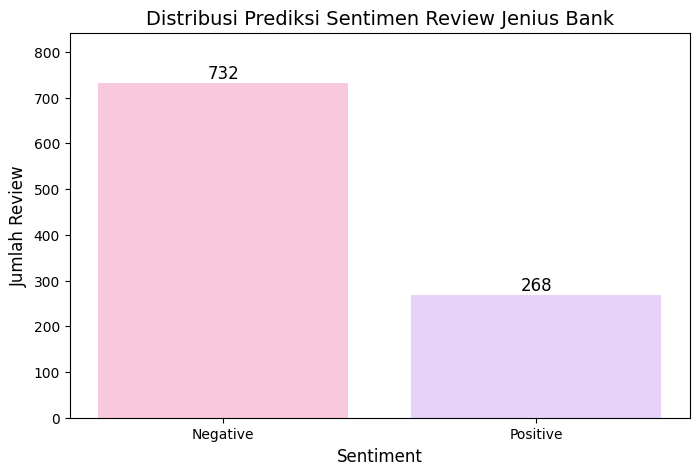

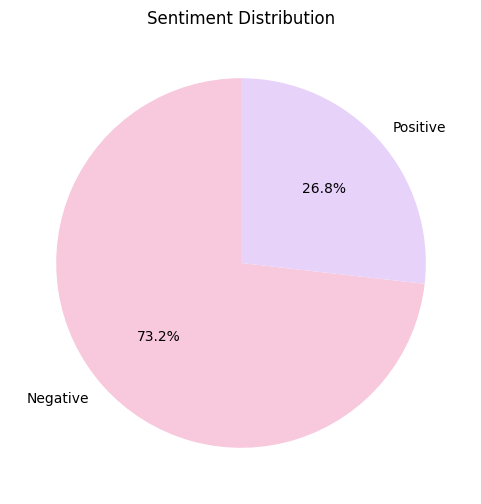

In [15]:
import matplotlib.pyplot as plt

# Hitung jumlah masing-masing sentimen
sentiment_counts = df_filtered_columns['sentiment_label'].value_counts()

# Membuat Bar Chart
plt.figure(figsize=(8, 5))
bars = plt.bar(
    sentiment_counts.index,
    sentiment_counts.values,
    color=['#F8C8DC', "#E7D3FA"]
)

# Menambahkan judul dan label sumbu
plt.title('Distribusi Prediksi Sentimen Review Jenius Bank', fontsize=14)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Jumlah Review', fontsize=12)

# Menambahkan angka (label) di atas setiap bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontsize=12)

# Tampilkan grafik
plt.ylim(0, max(sentiment_counts.values) + max(sentiment_counts.values)*0.15) # Memberi ruang kosong di atas bar
plt.show()

plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    colors=['#F8C8DC', '#E7D3FA'],
    startangle=90
)

plt.title('Sentiment Distribution')
plt.show()
     

#### **BAR CHART** ####    
**Bar Chart digunakan untuk menampilkan jumlah ulasan yang termasuk ke dalam kategori sentimen positif dan negatif. Melalui grafik ini dapat diketahui sentimen mana yang lebih dominan dalam ulasan pengguna Jenius Bank. Jika batang positif lebih tinggi, maka mayoritas pengguna memberikan tanggapan yang baik terhadap aplikasi.**

#### **PIE CHART** ####   
**Pie Chart digunakan untuk menunjukkan proporsi masing-masing sentimen terhadap keseluruhan data.**

**Positive = 26.8%**            
**Negative = 73.2%**

**Maka dapat disimpulkan bahwa sebagian besar pengguna memberikan ulasan positif terhadap aplikasi Jenius Bank. Visualisasi ini mempermudah interpretasi hasil analisis sentimen secara keseluruhan.**